## Nome:Mayara Cristina
## Matrícula:574

# Atividade 6 — Refinamento de Raízes: Método de Newton-Raphson
## Contexto: Nós de uma Função de Onda Quântica

Na disciplina de F04 (Física Moderna e Quântica), os **nós de uma função de onda** representam posições nas quais a amplitude de probabilidade é nula. Em um modelo simplificado relacionado ao oscilador harmônico quântico, a parte polinomial de uma função de onda pode ser representada por:

$$\psi(x)=4x^3-6x$$

Para aplicar o método de Newton-Raphson, utiliza-se sua derivada:

$${\psi}'(x)=12x^2-6$$

Nesta atividade, o objetivo é localizar numericamente os valores de $x$ para os quais $\psi(x)=0$ e analisar como o chute inicial e a tolerância influenciam a convergência.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 4*x**3 - 6*x

def df(x):
    return 12*x**2 - 6

In [ ]:
def newton_raphson(x0, tol=1e-9, max_iter=100):
    x = x0
    for i in range(max_iter):
        if abs(f(x)) < tol:
            return x, i
        if abs(df(x)) < 1e-12:
            raise ValueError("Derivada muito próxima de zero. Escolha outro chute inicial.")
        x = x - f(x)/df(x)
    return x, max_iter

## Parte Prática
1. Plote $f(x)$ no intervalo $[-2;2]$, indicando com uma linha tracejada o eixo $y=0$ e identificando visualmente as possíveis raízes.

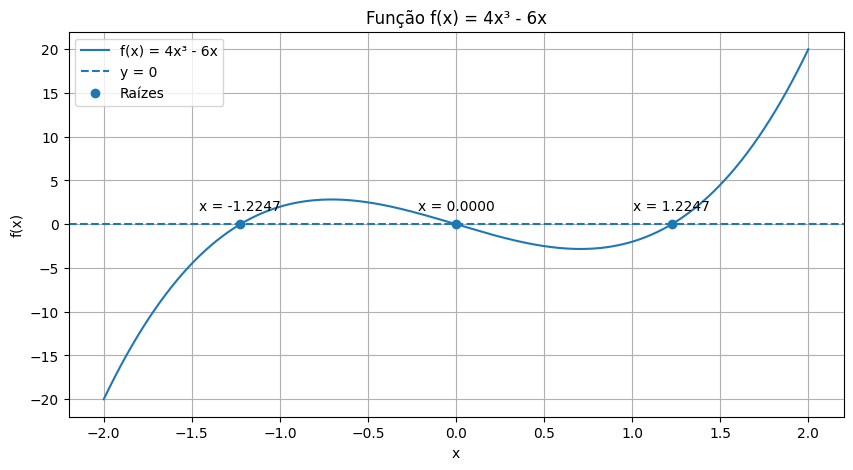

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 4*x**3 - 6*x

def df(x):
    return 12*x**2 - 6

x = np.linspace(-2, 2, 500)
y = f(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label='f(x) = 4x³ - 6x')
plt.axhline(0, linestyle='--', label='y = 0')

# Raízes
raizes = [-np.sqrt(3/2), 0, np.sqrt(3/2)]

plt.scatter(raizes, [0, 0, 0], zorder=5, label='Raízes')

for raiz in raizes:
    plt.annotate(f'x = {raiz:.4f}',
                 (raiz, 0),
                 xytext=(0, 10),
                 textcoords='offset points',
                 ha='center')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Função f(x) = 4x³ - 6x')
plt.grid()
plt.legend()
plt.show()

2. Aplique o método de Newton-Raphson utilizando o chute inicial $x_0=1{,}8$. Apresente a raiz aproximada e o número de iterações.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Função
def f(x):
    return 4*x**3 - 6*x

# Derivada da função
def df(x):
    return 12*x**2 - 6

# Método de Newton-Raphson
def newton_raphson(x0, tol=1e-9, max_iter=100):
    x = x0

    for i in range(max_iter):

        # Verifica se chegou suficientemente perto da raiz
        if abs(f(x)) < tol:
            return x, i

        # Verifica se a derivada está próxima de zero
        if abs(df(x)) < 1e-12:
            raise ValueError("Derivada muito próxima de zero. Escolha outro chute inicial.")

        # Fórmula de Newton-Raphson
        x = x - f(x) / df(x)

    return x, max_iter


# Chute inicial
x0 = 1.8

# Aplicando o método
raiz, iteracoes = newton_raphson(x0)

# Mostrando os resultados
print("Chute inicial:", x0)
print("Raiz aproximada:", raiz)
print("Número de iterações:", iteracoes)

Chute inicial: 1.8
Raiz aproximada: 1.2247448713969942
Número de iterações: 5


3. Teste os chutes iniciais $(-2{,}0; -1{,}0; -0{,}4; 0{,}2; 0{,}8; 1{,}6)$ e compare a raiz encontrada e o número de iterações em cada caso.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Função
def f(x):
    return 4*x**3 - 6*x

# Derivada da função
def df(x):
    return 12*x**2 - 6

# Método de Newton-Raphson
def newton_raphson(x0, tol=1e-9, max_iter=100):
    x = x0

    for i in range(max_iter):

        # Verifica se encontrou uma aproximação da raiz
        if abs(f(x)) < tol:
            return x, i

        # Verifica se a derivada está próxima de zero
        if abs(df(x)) < 1e-12:
            raise ValueError(
                "Derivada muito próxima de zero. Escolha outro chute inicial."
            )

        # Fórmula de Newton-Raphson
        x = x - f(x) / df(x)

    return x, max_iter


# Chutes iniciais solicitados
chutes = [-2.0, -1.0, -0.4, 0.2, 0.8, 1.6]

# Testando cada chute inicial
for chute in chutes:
    try:
        raiz, iteracoes = newton_raphson(chute)

        print("Chute inicial:", chute)
        print("Raiz encontrada:", raiz)
        print("Número de iterações:", iteracoes)
        print("-" * 40)

    except ValueError as erro:
        print("Chute inicial:", chute)
        print("Erro:", erro)
        print("-" * 40)

Chute inicial: -2.0
Raiz encontrada: -1.224744871391589
Número de iterações: 6
----------------------------------------
Chute inicial: -1.0
Raiz encontrada: -1.2247448713915905
Número de iterações: 5
----------------------------------------
Chute inicial: -0.4
Raiz encontrada: -2.6469779601696886e-23
Número de iterações: 4
----------------------------------------
Chute inicial: 0.2
Raiz encontrada: -1.1974928291807671e-17
Número de iterações: 3
----------------------------------------
Chute inicial: 0.8
Raiz encontrada: 1.2247448713937779
Número de iterações: 7
----------------------------------------
Chute inicial: 1.6
Raiz encontrada: 1.2247448713915896
Número de iterações: 5
----------------------------------------


4. Execute o método com as tolerâncias $10^{-3}$, $10^{-6}$ e $10^{-9}$, mantendo $x_0=1{,}8$. Analise o impacto da tolerância na aproximação da raiz e no número de iterações.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Função
def f(x):
    return 4*x**3 - 6*x

# Derivada da função
def df(x):
    return 12*x**2 - 6

# Método de Newton-Raphson
def newton_raphson(x0, tol=1e-9, max_iter=100):
    x = x0

    for i in range(max_iter):

        # Verifica se a aproximação já é suficientemente próxima da raiz
        if abs(f(x)) < tol:
            return x, i

        # Verifica se a derivada está próxima de zero
        if abs(df(x)) < 1e-12:
            raise ValueError(
                "Derivada muito próxima de zero. Escolha outro chute inicial."
            )

        # Fórmula de Newton-Raphson
        x = x - f(x) / df(x)

    return x, max_iter


# Chute inicial fixo
x0 = 1.8

# Tolerâncias solicitadas
tolerancias = [1e-3, 1e-6, 1e-9]

# Testando cada tolerância
for tol in tolerancias:
    raiz, iteracoes = newton_raphson(x0, tol=tol)

    print("Tolerância:", tol)
    print("Raiz aproximada:", raiz)
    print("Número de iterações:", iteracoes)
    print("-" * 40)

Tolerância: 0.001
Raiz aproximada: 1.2247469721871977
Número de iterações: 4
----------------------------------------
Tolerância: 1e-06
Raiz aproximada: 1.2247448713969942
Número de iterações: 5
----------------------------------------
Tolerância: 1e-09
Raiz aproximada: 1.2247448713969942
Número de iterações: 5
----------------------------------------


## Parte Teórica

1. O que significa afirmar que o método de Newton-Raphson possui convergência quadrática próximo de uma raiz simples?

**Resposta:**
Significa que, próximo de uma raiz simples, o erro do método de Newton-Raphson diminui aproximadamente pelo quadrado a cada iteração, ou seja, a convergência é muito rápida.

2. Como o método pode ser adaptado quando a derivada da função não está disponível analiticamente?

**Resposta:**
Pode-se aproximar a derivada numericamente, usando diferenças finitas, em vez de calculá-la analiticamente. Outra opção é usar o método da secante, que não exige a derivada.

3. Compare o método de Newton-Raphson com o método da bissecção, destacando as vantagens e limitações de cada um.

**Resposta:**
Newton-Raphson: é mais rápido (convergência quadrática), mas depende de uma boa aproximação inicial e da derivada.

Bissecção: é mais lento (convergência linear), porém é mais seguro e garante a convergência quando há uma mudança de sinal no intervalo.

4. Quais problemas podem ocorrer durante a aplicação do método de Newton-Raphson? Cite pelo menos três e relacione um deles à possibilidade de a derivada ser igual ou muito próxima de zero.

**Resposta:**
Derivada igual ou próxima de zero: pode causar divisão por zero ou passos muito grandes, fazendo o método falhar.

Chute inicial inadequado: pode fazer o método convergir para outra raiz ou não convergir.

Oscilação ou divergência: as iterações podem se afastar da raiz em algumas funções.